In [36]:

# GPS User Localization Simulation
# --------------------------------
# The user is fixed at the position (100, 100, 100).
# Five satellites are placed at fixed positions.



In [37]:
# Part (a):
# Calculate the distance from each satellite to the user.
# Then calculate the signal travel time using:
#       time = distance / speed_of_light


import numpy as np
c = 299_792_458 


In [38]:
# Fixing Position of the user.
user = np.array([[100, 100, 100]])

In [39]:

# Fixing Positions of all 5 satellites.
satelite_1 = np.array([[4004, 3011, 7086]])
satelite_2 = np.array([[1002, 2106, 6013]])
satelite_3 = np.array([[7000, 2000, 5067]])
satelite_4 = np.array([[2030, 4000, 3000]])
satelite_5 = np.array([[3798, 9020, 2300]])

# Calculate the distance from each satellite to the user.
distance_u_to_s1 = np.linalg.norm(satelite_1 - user)
distance_u_to_s2 = np.linalg.norm(satelite_2 - user)
distance_u_to_s3 = np.linalg.norm(satelite_3 - user)
distance_u_to_s4 = np.linalg.norm(satelite_4 - user)
distance_u_to_s5 = np.linalg.norm(satelite_5 - user)

# Calculate the time it takes from each satellite to the user.
time1 = (distance_u_to_s1/c) * 1e6;
time2 = (distance_u_to_s2/c) * 1e6;
time3 = (distance_u_to_s3/c)* 1e6;
time4 = (distance_u_to_s4/c)* 1e6;
time5 = (distance_u_to_s5/c)* 1e6;

print("Signal Travel Times")
print("-" * 25)

print(f"Satellite 1 : {time1:.4f} μs")
print(f"Satellite 2 : {time2:.4f} μs")
print(f"Satellite 3 : {time3:.4f} μs")
print(f"Satellite 4 : {time4:.4f} μs")
print(f"Satellite 5 : {time5:.4f} μs")


Signal Travel Times
-------------------------
Satellite 1 : 28.4057 μs
Satellite 2 : 21.0440 μs
Satellite 3 : 29.0586 μs
Satellite 4 : 17.4429 μs
Satellite 5 : 33.0349 μs


In [40]:
# Part (b):
# Perform the reverse operation.
# Convert the measured signal times back into distances using:
#       distance = time * speed_of_light

# Use the satellite positions and these distances to estimate
# the unknown user position using least-squares optimization.

# Finally, compare the estimated position with the actual
# user position (100, 100, 100) and calculate the localization error.



In [41]:

distances = np.array([time1, time2, time3, time4,time5]) * 1e-6 * c

satellites = np.array([
    [4004, 3011, 7086],
    [1002, 2106, 6013],
    [7000, 2000, 5067],
    [2030, 4000, 3000],
    [3798, 9020, 2300]
])


In [42]:
def error(position):
    cal_dist = np.linalg.norm(satellites - position, axis=1)
    
    return (cal_dist - distances)


from scipy.optimize import least_squares

result = least_squares(error, [0, 0, 0])

estimated_user = result.x

print(estimated_user)



actual_user = np.array([100, 100, 100])

print("Estimated:", estimated_user)
print("Actual:   ", actual_user)
print("Error:    ", np.linalg.norm(estimated_user - actual_user))

[100. 100. 100.]
Estimated: [100. 100. 100.]
Actual:    [100 100 100]
Error:     1.1493234663700917e-12


In [43]:

# =========================================================
# PART (c): 
# =========================================================

# Store the original signal times
times = np.array([
    time1,
    time2,
    time3,
    time4,
    time5
])

# SD of time error in microseconds ie we are choosing how much timing uncertainty to introduce
timing_error_std = 0.018

# Random Error Generation for each satellite
random_error = np.random.normal(
    0,
    timing_error_std,
    5
)

# noisy time by adding errors and original times
noisy_times = times + random_error

print("Original times:", times)
print("Random errors:", random_error)
print("Noisy times:", noisy_times)

Original times: [28.40574588 21.04395814 29.05860018 17.44285083 33.03490611]
Random errors: [-0.00061993 -0.00262499 -0.01624687  0.00962086  0.00829726]
Noisy times: [28.40512595 21.04133315 29.04235331 17.4524717  33.04320337]


In [44]:
#Conversion of noisy times into distances
#1e-6 is because noisy_times is in microseconds.
noisy_distances = noisy_times * 1e-6 * c

In [45]:
# Estimate the user again
# error() function will now use noisy_distances instead of original distances

def error(position):
    calculated_distances = np.linalg.norm(
        satellites - position,
        axis=1
    )

    return calculated_distances - noisy_distances


result = least_squares(error, [0, 0, 0])

estimated_user = result.x

#Calculate localization error
localization_error = np.linalg.norm(
    estimated_user - actual_user
)

print("Estimated position:", estimated_user)
print("Actual position:   ", actual_user)
print("Localization error:", localization_error)

Estimated position: [106.50994241  93.54340436 100.85058271]
Actual position:    [100 100 100]
Localization error: 9.20817399896861



PART (d)
**************************************************
Timing Error (μs)   Average Localization Error    
**************************************************
0.0150              9.4400                        
0.0030              1.8757                        
0.0900              56.2886                       
0.0530              35.3464                       
0.1200              71.6995                       
0.7000              430.6725                      


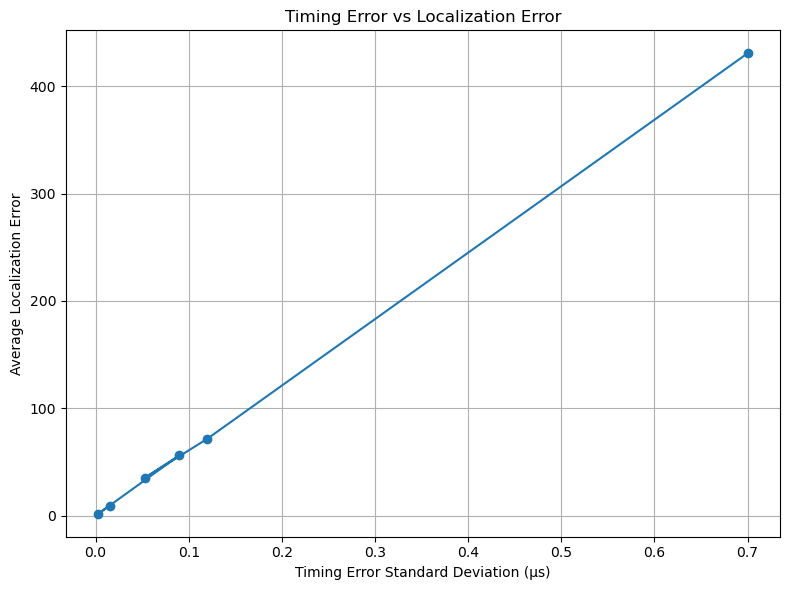

In [46]:

# PART (d): Increase timing errors

# Different timing error
timing_errors = [
    0.0029,
    0.0151,
    0.0513,
    0.0901,
    0.13,
    0.9
]

# we are running the program multiple time and so we can take the average localization errors
sim_num = 120

avg_local_errors = []


for timing_error in timing_errors:
    
    #Creating a list for the 120 experiments
    localiz_errors = []

    # Repeating the simulation many times
    for _ in range(sim_num):

        # Generation of random timing errors
        rand_error = np.random.normal(
            0,
            timing_error,
            5
        )

        #noisy time by adding errors and original times
        noisy_times = times + rand_error

        #Conversion of noisy times into distances
        noisy_dist = noisy_times * 1e-6 * c

        # Error function
        def error(position):
            cal_dist = np.linalg.norm(
                satellites - position,
                axis=1
            )

            return cal_dist - noisy_dist

        # Estimate user position
        result = least_squares(
            error,
            [0, 0, 0]
        )

        estimated_user = result.x

        # Calculate localization error
        localiz_error = np.linalg.norm(
            estimated_user - actual_user
        )

        localiz_errors.append(localiz_error)

    # Calculate average localization error
    avg_error = np.mean(localiz_errors)
    avg_local_errors.append(avg_error)



# Part (d) results
print("\nPART (d)")
print("*" * 50)

print(
    f"{'Timing Error (μs)':<20}"
    f"{'Average Localization Error':<30}"
)

print("*" * 50)

for timing_error, avg_error in zip(
    timing_errors,
    avg_local_errors
):

    print(
        f"{timing_error:<20.4f}"
        f"{avg_error:<30.4f}"
    )


# Graph Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    timing_errors,
    avg_local_errors,
    marker='o'
)

plt.xlabel("Timing Error Standard Deviation (μs)")
plt.ylabel("Average Localization Error")
plt.title("Timing Error vs Localization Error")

plt.grid(True)
plt.tight_layout()

plt.show()